# Notebook 2 — Machine Learning Pipeline

**Objective.** Train and compare three classifiers that predict the emotion
**label** (`positiv` / `neutral` / `negativ`) from the **plant bioelectric
features** of each 30-second window, and identify the best-performing model.

**Models compared**
1. **Random Forest** (bagged decision trees)
2. **XGBoost** (gradient-boosted trees)
3. **Neural Network** (multi-layer perceptron)

**Pipeline overview**
1. Load the consolidated dataset (output of Notebook 1)
2. Select and engineer features (`label_confidence` + plant features Q–AL)
3. Clean: handle missing values, encode categoricals, drop redundant columns
4. Split into train / validation / test **without participant leakage**
5. Scale features
6. Hyperparameter tuning via **Randomised Search** (per model)
7. Evaluate: accuracy, F1, ROC-AUC, confusion matrix, classification report
8. Compare models, inspect feature importance, discuss findings

> **Note on dataset size.** This is an exploratory study (N ≈ 10–15
> participants). The absolute scores matter less than the *relative* comparison
> of the three approaches and the methodology, which is built to scale to a
> larger cohort without changes.


## 1  Imports & Configuration

We fix a global `RANDOM_STATE` for full reproducibility. XGBoost is optional —
if it is not installed the notebook still runs the other two models and says so.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, GroupShuffleSplit
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
except ImportError:
    XGBOOST_OK = False
    print("xgboost not installed — pip install xgboost (XGBoost model will be skipped)")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATASET_CSV = Path("./consolidated_dataset.csv")   # output of Notebook 1
print(f"Dataset: {DATASET_CSV.resolve()}")
print(f"XGBoost available: {XGBOOST_OK}")


Dataset: /Users/jakobjetter/Documents/Universität zu Köln/2. Semester/COIN Seminar/Project/COIN2026_Team-1_Plant-Emotion-Detector/notebooks/consolidated_dataset.csv
XGBoost available: True


## 2  Load the Consolidated Dataset

We load the single CSV produced by Notebook 1 and take a first look at its
shape, columns and the class balance of the target.


In [2]:
df = pd.read_csv(DATASET_CSV)
print(f"Loaded {df.shape[0]} rows × {df.shape[1]} columns\n")
print("Target (label) distribution:")
print(df["label"].value_counts().to_string())
print("\nClass balance:")
print(df["label"].value_counts(normalize=True).mul(100).round(1).astype(str).add(' %').to_string())
df.head()


Loaded 456 rows × 42 columns

Target (label) distribution:
label
neutral    205
positiv    142
negativ    109

Class balance:
label
neutral    45.0 %
positiv    31.1 %
negativ    23.9 %


,session_id,proband_id,session_date,win_start_ms,win_end_ms,label,agreement,label_confidence,reason,rmssd,...,bp_0_1,bp_1_5,bp_5_15,bp_15_30,bp_30_50,total_power,plant_quality,plant_dead_flag,plant_suspect_flag,co2_mean
0,2026-06-22_18-35_proband_01,proband_01,2026-06-22,1782146164840,1782146194840,negativ,hrv_only,0.450,rz=-0.85 hz=+2.09 fer=neutral,19.109185,...,0.000075,0.000085,0.000043,0.000010,0.000005,0.000219,ok,False,False,561.2
1,2026-06-22_18-35_proband_01,proband_01,2026-06-22,1782146169840,1782146199840,negativ,confirmed,0.935,rz=-0.62 hz=+2.04 fer=negativ,20.459263,...,0.000074,0.000084,0.000043,0.000010,0.000005,0.000216,ok,False,False,562.4
2,2026-06-22_18-35_proband_01,proband_01,2026-06-22,1782146174840,1782146204840,neutral,conflict,0.193,rz=-0.51 hz=+1.53 fer=negativ,21.072939,...,0.000046,0.000024,0.000007,0.000008,0.000005,0.000089,ok,False,False,564.0
3,2026-06-22_18-35_proband_01,proband_01,2026-06-22,1782146179840,1782146209840,negativ,hrv_only,0.378,rz=-0.61 hz=+1.37 fer=neutral,20.542791,...,0.000014,0.000005,0.000002,0.000008,0.000005,0.000035,ok,False,False,565.8
4,2026-06-22_18-35_proband_01,proband_01,2026-06-22,1782146184840,1782146214840,negativ,hrv_only,0.412,rz=-0.86 hz=+1.48 fer=neutral,19.044853,...,0.000013,0.000006,0.000002,0.000008,0.000005,0.000034,ok,False,False,567.4


## 3  Feature Selection & Inspection

### Target
The prediction target is **`label`** (`positiv` / `neutral` / `negativ`).

### Candidate features
Following the task specification, the initial feature set is **`label_confidence`
plus the plant-related features (spreadsheet columns Q–AL)**:

| Range | Columns |
|---|---|
| `label_confidence` | confidence of the HRV/FER label |
| Q–Z | `plant_n_samples`, `plant_mean`, `plant_median`, `plant_std`, `plant_iqr`, `plant_min`, `plant_max`, `plant_range`, `plant_rms`, `plant_zcr` |
| AA–AC | `plant_sat_pos_frac`, `plant_sat_neg_frac`, `plant_const_flag` |
| AD–AI | `bp_0_1`, `bp_1_5`, `bp_5_15`, `bp_15_30`, `bp_30_50`, `total_power` |
| AJ–AL | `plant_quality`, `plant_dead_flag`, `plant_suspect_flag` |

### Why *not* the HRV/FER columns?
Columns `rmssd`…`fer_dominant_emotion` are exactly what the label was *derived
from*. Feeding them back as predictors would be **target leakage** — the model
would simply re-learn the labelling rule, not the relationship between the
**plant signal** and emotion, which is the scientific question. We therefore
restrict predictors to plant features (+ `label_confidence`, kept as an
optional quality covariate).

We inspect each candidate for usefulness before committing.


In [3]:
# Define the candidate feature columns (label_confidence + plant features Q-AL)
plant_features = [
    "plant_n_samples",
    "plant_mean", "plant_median", "plant_std", "plant_iqr",
    "plant_min", "plant_max", "plant_range", "plant_rms", "plant_zcr",
    "plant_sat_pos_frac", "plant_sat_neg_frac", "plant_const_flag",
    "bp_0_1", "bp_1_5", "bp_5_15", "bp_15_30", "bp_30_50", "total_power",
    "plant_quality", "plant_dead_flag", "plant_suspect_flag",
]
candidate_features = plant_features

# Keep only those actually present (robust to schema variations)
candidate_features = [c for c in candidate_features if c in df.columns]
print(f"{len(candidate_features)} candidate features present.\n")

# Inspect dtypes, missingness and variance
inspect = pd.DataFrame({
    "dtype":     df[candidate_features].dtypes.astype(str),
    "n_missing": df[candidate_features].isna().sum(),
    "n_unique":  df[candidate_features].nunique(),
})
print(inspect.to_string())


22 candidate features present.

                      dtype  n_missing  n_unique
plant_n_samples       int64          0        99
plant_mean          float64          0       446
plant_median        float64          0       437
plant_std           float64          0       434
plant_iqr           float64          0       438
plant_min           float64          0       137
plant_max           float64          0       134
plant_range         float64          0       218
plant_rms           float64          0       444
plant_zcr           float64          0       444
plant_sat_pos_frac  float64          0         1
plant_sat_neg_frac  float64          0         1
plant_const_flag       bool          0         1
bp_0_1              float64          0       456
bp_1_5              float64          0       456
bp_5_15             float64          0       456
bp_15_30            float64          0       456
bp_30_50            float64          0       456
total_power         float64          

### Removing redundant / non-informative features

We drop features that cannot help the model:

- **Constant columns** (`n_unique == 1`) carry no information. In a clean
  recording `plant_const_flag` is always `False` and `plant_sat_*` are 0 — if
  so they are dropped automatically.
- **`plant_quality`** is a categorical *summary* of `plant_std` / saturation; we
  keep the boolean `plant_dead_flag` / `plant_suspect_flag` instead (cleaner for
  modelling) and one-hot `plant_quality` only if it varies.
- **`plant_n_samples`** is a coverage/QA field (≈3800 for every full window),
  not a physiological signal — dropped if near-constant.

This is done data-driven below, so it adapts to whatever the real recordings
contain.


In [4]:
# Drop constant candidate features (no information)
nunique = df[candidate_features].nunique()
constant_cols = nunique[nunique <= 1].index.tolist()
if constant_cols:
    print(f"Dropping {len(constant_cols)} constant feature(s): {constant_cols}")
candidate_features = [c for c in candidate_features if c not in constant_cols]

# plant_n_samples: drop if near-constant (coverage QA, not signal)
if "plant_n_samples" in df.columns and df["plant_n_samples"].std() < 1e-6:
    if "plant_n_samples" in candidate_features:
        candidate_features.remove("plant_n_samples")
        print("Dropping 'plant_n_samples' (near-constant coverage field).")

print(f"\n{len(candidate_features)} features remain after redundancy removal:")
print(candidate_features)


Dropping 4 constant feature(s): ['plant_sat_pos_frac', 'plant_sat_neg_frac', 'plant_const_flag', 'plant_dead_flag']

18 features remain after redundancy removal:
['plant_n_samples', 'plant_mean', 'plant_median', 'plant_std', 'plant_iqr', 'plant_min', 'plant_max', 'plant_range', 'plant_rms', 'plant_zcr', 'bp_0_1', 'bp_1_5', 'bp_5_15', 'bp_15_30', 'bp_30_50', 'total_power', 'plant_quality', 'plant_suspect_flag']


## 4  Preprocessing: Missing Values & Encoding

**Missing values.** Spectral features can be `NaN` for windows that were too
short or flat for a Welch PSD. We:
- drop rows whose target is missing,
- impute remaining numeric `NaN`s with the **median** (robust to outliers).

**Categorical encoding.** `plant_quality` (if kept) is one-hot encoded. Boolean
flags are cast to integers (0/1).

**Quality filtering.** Windows flagged `plant_dead_flag` are electrode-failure
artefacts with no usable plant signal; we drop them from the modelling set
(kept configurable).


In [5]:
DROP_DEAD_WINDOWS = True   # exclude electrode-failure windows from modelling

work = df.copy()

# 1) Drop rows with missing target
work = work.dropna(subset=["label"]).reset_index(drop=True)

# 2) Optionally drop dead-electrode windows
if DROP_DEAD_WINDOWS and "plant_dead_flag" in work.columns:
    before = len(work)
    # plant_dead_flag may be bool or string "True"/"False"
    dead = work["plant_dead_flag"].astype(str).str.lower().isin(["true", "1"])
    work = work[~dead].reset_index(drop=True)
    print(f"Dropped {before - len(work)} dead-electrode windows "
          f"({len(work)} rows remain).")

# 3) Cast boolean flags to int
for col in ["plant_const_flag", "plant_dead_flag", "plant_suspect_flag"]:
    if col in work.columns:
        work[col] = work[col].astype(str).str.lower().isin(["true", "1"]).astype(int)

# 4) One-hot encode plant_quality if it is in the feature set and varies
encoded_cols = []
if "plant_quality" in candidate_features:
    if work["plant_quality"].nunique() > 1:
        dummies = pd.get_dummies(work["plant_quality"], prefix="quality").astype(int)
        work = pd.concat([work, dummies], axis=1)
        encoded_cols = dummies.columns.tolist()
        print(f"One-hot encoded plant_quality → {encoded_cols}")
    candidate_features.remove("plant_quality")   # replaced by dummies (or dropped if constant)

feature_cols = candidate_features + encoded_cols

# 5) Median-impute remaining numeric NaNs
X = work[feature_cols].apply(pd.to_numeric, errors="coerce")
n_missing = X.isna().sum().sum()
if n_missing:
    print(f"Imputing {n_missing} missing numeric values with column medians.")
    X = X.fillna(X.median(numeric_only=True))

y = work["label"].astype(str)
groups = work["proband_id"] if "proband_id" in work.columns else pd.Series(range(len(work)))

print(f"\nFinal design matrix: {X.shape[0]} rows × {X.shape[1]} features")
print(f"Features: {feature_cols}")
print(f"\nTarget distribution after cleaning:")
print(y.value_counts().to_string())


Dropped 0 dead-electrode windows (456 rows remain).
One-hot encoded plant_quality → ['quality_ok', 'quality_suspect_lowamp']

Final design matrix: 456 rows × 19 features
Features: ['plant_n_samples', 'plant_mean', 'plant_median', 'plant_std', 'plant_iqr', 'plant_min', 'plant_max', 'plant_range', 'plant_rms', 'plant_zcr', 'bp_0_1', 'bp_1_5', 'bp_5_15', 'bp_15_30', 'bp_30_50', 'total_power', 'plant_suspect_flag', 'quality_ok', 'quality_suspect_lowamp']

Target distribution after cleaning:
label
neutral    205
positiv    142
negativ    109


## 5  Train / Validation / Test Split (leakage-safe)

A naive random split would put windows from the **same participant** in both
train and test. Because consecutive windows from one person are highly
correlated, that inflates scores — the model "recognises the person", not the
emotion. This is **data leakage**.

We therefore split by **participant group** when more than one participant is
available (`GroupShuffleSplit`): no participant appears in more than one split.
With only a single participant (e.g. during piloting) we fall back to a
**stratified** random split and warn that scores will be optimistic.

Target proportions: **60 % train / 20 % validation / 20 % test**.


In [6]:
def grouped_split(X, y, groups, random_state=RANDOM_STATE):
    """Participant-aware 60/20/20 split. Falls back to stratified split
    if only one group is present."""
    n_groups = pd.Series(groups).nunique()

    if n_groups >= 3:
        # First carve off 20% test by group
        gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=random_state)
        trainval_idx, test_idx = next(gss1.split(X, y, groups))
        X_tv, y_tv, g_tv = X.iloc[trainval_idx], y.iloc[trainval_idx], groups.iloc[trainval_idx]
        # Then 0.25 of the remaining 80% → 20% validation
        gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=random_state)
        train_idx, val_idx = next(gss2.split(X_tv, y_tv, g_tv))
        split = {
            "X_train": X_tv.iloc[train_idx], "y_train": y_tv.iloc[train_idx],
            "X_val":   X_tv.iloc[val_idx],   "y_val":   y_tv.iloc[val_idx],
            "X_test":  X.iloc[test_idx],     "y_test":  y.iloc[test_idx],
        }
        mode = f"participant-grouped ({n_groups} participants)"
    else:
        # Fallback: stratified random split
        X_tv, X_test, y_tv, y_test = train_test_split(
            X, y, test_size=0.20, random_state=random_state, stratify=y)
        X_train, X_val, y_train, y_val = train_test_split(
            X_tv, y_tv, test_size=0.25, random_state=random_state, stratify=y_tv)
        split = {"X_train":X_train,"y_train":y_train,"X_val":X_val,
                 "y_val":y_val,"X_test":X_test,"y_test":y_test}
        mode = "stratified random (single participant — scores will be optimistic)"
    return split, mode


S, split_mode = grouped_split(X, y, groups)
print(f"Split mode: {split_mode}\n")
for name in ["train", "val", "test"]:
    Xs, ys = S[f"X_{name}"], S[f"y_{name}"]
    print(f"  {name:<5}: {len(Xs):4d} rows   class counts = {dict(ys.value_counts())}")


Split mode: stratified random (single participant — scores will be optimistic)

  train:  273 rows   class counts = {'neutral': np.int64(123), 'positiv': np.int64(85), 'negativ': np.int64(65)}
  val  :   91 rows   class counts = {'neutral': np.int64(41), 'positiv': np.int64(28), 'negativ': np.int64(22)}
  test :   92 rows   class counts = {'neutral': np.int64(41), 'positiv': np.int64(29), 'negativ': np.int64(22)}


## 6  Feature Scaling

Tree models (Random Forest, XGBoost) are scale-invariant, but the **neural
network** is highly sensitive to feature scale. We fit a `StandardScaler` **on
the training set only** and apply it to validation and test — fitting on the
full data would leak test-set statistics into training.

We keep both scaled and unscaled versions: trees use the raw features (more
interpretable importances), the MLP uses the scaled ones.


In [7]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(S["X_train"]),
                              columns=X.columns, index=S["X_train"].index)
X_val_scaled   = pd.DataFrame(scaler.transform(S["X_val"]),
                              columns=X.columns, index=S["X_val"].index)
X_test_scaled  = pd.DataFrame(scaler.transform(S["X_test"]),
                              columns=X.columns, index=S["X_test"].index)

print("Scaler fitted on training set only (no leakage).")
print(f"Example — feature means after scaling (train ≈ 0): "
      f"{np.round(X_train_scaled.mean().mean(), 4)}")
print(f"          feature means after scaling (test): "
      f"{np.round(X_test_scaled.mean().mean(), 4)}")

# Encode the target to integers for the models that need it
classes = sorted(y.unique())
class_to_int = {c: i for i, c in enumerate(classes)}
int_to_class = {i: c for c, i in class_to_int.items()}
y_train_enc = S["y_train"].map(class_to_int)
y_val_enc   = S["y_val"].map(class_to_int)
y_test_enc  = S["y_test"].map(class_to_int)
print(f"\nClasses: {classes}  →  encoded as {list(range(len(classes)))}")


Scaler fitted on training set only (no leakage).
Example — feature means after scaling (train ≈ 0): 0.0
          feature means after scaling (test): 0.0368

Classes: ['negativ', 'neutral', 'positiv']  →  encoded as [0, 1, 2]


## 7  Hyperparameter Optimisation (Randomised Search)

For each model we run **`RandomizedSearchCV`** — it samples a fixed number of
configurations from a search space and cross-validates each. Randomised search
is more efficient than grid search when some hyperparameters matter more than
others, and it gives a controlled compute budget (`N_ITER`).

**Robustness settings:**
- **5-fold *stratified* cross-validation** (`StratifiedKFold`, shuffled with a
  fixed seed) keeps the 3-class balance in every fold and makes the folds
  deterministic across runs.
- **`N_ITER = 60`** configurations sampled per model (a larger search than the
  baseline) to explore the enlarged parameter spaces more thoroughly.
- **`return_train_score`** lets us print the train-vs-CV gap as an
  overfitting check; **`error_score=0`** stops a single failed fit from
  aborting the whole search.

Cross-validation is done **inside the training set only**; the validation set is
kept aside to compare the tuned models *before* we ever touch the test set.
Both `N_ITER` and `CV_FOLDS` are single constants you can raise for the full
cohort.


In [8]:
from sklearn.model_selection import StratifiedKFold

# ── Hyperparameter search budget ────────────────────────────────
# Enlarged from the baseline (was N_ITER=25, CV_FOLDS=4) for a more thorough
# and more robust optimisation. These remain single constants you can raise
# further for the full cohort.
N_ITER   = 60     # configurations sampled per model (was 25)
CV_FOLDS = 5      # 5-fold cross-validation (was 4)
SCORING  = "f1_macro"   # macro-F1: treats all three classes equally

# Robust, reproducible CV splitter: stratified keeps the 3-class balance in
# every fold; shuffle + fixed seed makes the folds deterministic across runs.
CV = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def tune(estimator, param_dist, X_tr, y_tr, name):
    """Run RandomizedSearchCV with stratified k-fold CV and report the best
    configuration. error_score=0 prevents a single failed fit from aborting
    the whole search; return_train_score enables an overfitting check."""
    search = RandomizedSearchCV(
        estimator, param_distributions=param_dist,
        n_iter=N_ITER, scoring=SCORING, cv=CV,
        random_state=RANDOM_STATE, n_jobs=-1, refit=True, verbose=0,
        return_train_score=True, error_score=0,
    )
    search.fit(X_tr, y_tr)
    best_idx   = search.best_index_
    train_mean = search.cv_results_["mean_train_score"][best_idx]
    val_mean   = search.cv_results_["mean_test_score"][best_idx]
    val_std    = search.cv_results_["std_test_score"][best_idx]
    print(f"[{name}] best CV {SCORING} = {val_mean:.3f} ± {val_std:.3f}  "
          f"(train {train_mean:.3f}, gap {train_mean - val_mean:+.3f})")
    print(f"[{name}] best params = {search.best_params_}")
    return search.best_estimator_


## 8  Model 1 — Random Forest

A bagging ensemble of decision trees. Robust, needs little preprocessing, and
gives interpretable feature importances. Trees are scale-invariant, so we use
the **unscaled** training features. `class_weight="balanced"` compensates for
the class imbalance.


In [9]:
rf_space = {
    "n_estimators":      [100, 200, 300, 400, 600, 800],
    "max_depth":         [None, 4, 6, 8, 12, 16, 24],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf":  [1, 2, 4, 8],
    "max_features":      ["sqrt", "log2", None, 0.5],
    "bootstrap":         [True, False],
    "criterion":         ["gini", "entropy"],
}
rf = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE)
rf_best = tune(rf, rf_space, S["X_train"], y_train_enc, "RandomForest")


[RandomForest] best CV f1_macro = 0.534 ± 0.086  (train 0.998, gap +0.464)
[RandomForest] best params = {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 24, 'criterion': 'entropy', 'bootstrap': True}


## 9  Model 2 — XGBoost

Gradient-boosted trees: builds trees sequentially, each correcting the previous
one's errors. Often the strongest tabular model. Also scale-invariant, so it
uses the unscaled training features.


In [10]:
if XGBOOST_OK:
    xgb_space = {
        "n_estimators":     [100, 200, 300, 500, 800],
        "max_depth":        [3, 4, 5, 6, 8, 10],
        "learning_rate":    [0.01, 0.03, 0.05, 0.1, 0.2],
        "subsample":        [0.6, 0.7, 0.85, 1.0],
        "colsample_bytree": [0.6, 0.7, 0.85, 1.0],
        "min_child_weight": [1, 2, 3, 5, 7],
        "gamma":            [0, 0.1, 0.3, 0.5],
        "reg_lambda":       [0.5, 1.0, 2.0, 5.0],
        "reg_alpha":        [0, 0.1, 0.5, 1.0],
    }
    xgb = XGBClassifier(
        objective="multi:softprob", num_class=len(classes),
        eval_metric="mlogloss", random_state=RANDOM_STATE,
        tree_method="hist",
    )
    xgb_best = tune(xgb, xgb_space, S["X_train"], y_train_enc, "XGBoost")
else:
    xgb_best = None
    print("XGBoost skipped (library not installed).")


[XGBoost] best CV f1_macro = 0.576 ± 0.016  (train 1.000, gap +0.424)
[XGBoost] best params = {'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 800, 'min_child_weight': 2, 'max_depth': 6, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.7}


## 10  Model 3 — Neural Network (MLP)

A multi-layer perceptron. Neural networks need **scaled** inputs, so it trains
on the standardised features. We tune the hidden-layer architecture, activation,
regularisation (`alpha`) and learning rate. Early stopping guards against
over-fitting on this small dataset.


In [11]:
mlp_space = {
    "hidden_layer_sizes": [(32,), (64,), (128,), (64, 32), (128, 64),
                           (128, 64, 32), (64, 32, 16), (256, 128)],
    "activation":         ["relu", "tanh"],
    "alpha":              [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    "learning_rate_init": [5e-4, 1e-3, 5e-3, 1e-2],
    "batch_size":         [16, 32, 64],
    "learning_rate":      ["constant", "adaptive"],
}
mlp = MLPClassifier(
    solver="adam", max_iter=800, early_stopping=True,
    n_iter_no_change=25, random_state=RANDOM_STATE,
)
mlp_best = tune(mlp, mlp_space, X_train_scaled, y_train_enc, "NeuralNet")


[NeuralNet] best CV f1_macro = 0.469 ± 0.075  (train 0.704, gap +0.235)
[NeuralNet] best params = {'learning_rate_init': 0.005, 'learning_rate': 'constant', 'hidden_layer_sizes': (64, 32, 16), 'batch_size': 32, 'alpha': 1e-05, 'activation': 'tanh'}


## 11  Validation-Set Comparison (before testing)

We compare the three tuned models on the **validation set** — data they were
*not* trained on but which we use for model selection. The test set stays
untouched until the final evaluation, so it remains an honest estimate of
generalisation.

Each model uses the feature representation it was tuned on (trees: unscaled,
MLP: scaled).


In [12]:
def evaluate(model, X_eval, y_eval_enc, scaled=False):
    """Return accuracy, macro-F1 and (if possible) macro ROC-AUC."""
    Xe = X_eval
    y_pred = model.predict(Xe)
    acc = accuracy_score(y_eval_enc, y_pred)
    f1  = f1_score(y_eval_enc, y_pred, average="macro")
    # ROC-AUC (one-vs-rest, macro) needs probabilities
    try:
        y_proba = model.predict_proba(Xe)
        present = sorted(np.unique(y_eval_enc))
        y_bin = label_binarize(y_eval_enc, classes=list(range(len(classes))))
        auc = roc_auc_score(y_bin, y_proba, average="macro", multi_class="ovr")
    except Exception:
        auc = np.nan
    return {"accuracy": acc, "f1_macro": f1, "roc_auc": auc}

val_results = {}
val_results["RandomForest"] = evaluate(rf_best, S["X_val"], y_val_enc)
if xgb_best is not None:
    val_results["XGBoost"] = evaluate(xgb_best, S["X_val"], y_val_enc)
val_results["NeuralNet"] = evaluate(mlp_best, X_val_scaled, y_val_enc)

val_df = pd.DataFrame(val_results).T.round(3)
print("Validation-set performance:\n")
print(val_df.to_string())

best_model_name = val_df["f1_macro"].idxmax()
print(f"\n→ Best model on validation (macro-F1): {best_model_name}")


Validation-set performance:

              accuracy  f1_macro  roc_auc
RandomForest     0.593     0.586    0.759
XGBoost          0.659     0.649    0.777
NeuralNet        0.396     0.381    0.581

→ Best model on validation (macro-F1): XGBoost


## 12  Final Evaluation on the Test Set

Now — and only now — we evaluate all tuned models on the **held-out test set**.
For each model we report accuracy, macro-F1 and macro ROC-AUC, and we draw the
confusion matrix and full classification report.


In [13]:
def full_report(model, X_te, y_te_enc, name):
    y_pred = model.predict(X_te)
    metrics = evaluate(model, X_te, y_te_enc)
    print("=" * 60)
    print(f"  {name} — TEST SET")
    print("=" * 60)
    print(f"Accuracy : {metrics['accuracy']:.3f}")
    print(f"Macro-F1 : {metrics['f1_macro']:.3f}")
    print(f"ROC-AUC  : {metrics['roc_auc']:.3f}")
    print("\nClassification report:")
    print(classification_report(
        y_te_enc, y_pred,
        labels=list(range(len(classes))),
        target_names=classes, zero_division=0))
    return metrics, y_pred

test_results, test_preds = {}, {}

m, p = full_report(rf_best, S["X_test"], y_test_enc, "Random Forest")
test_results["RandomForest"], test_preds["RandomForest"] = m, p

if xgb_best is not None:
    m, p = full_report(xgb_best, S["X_test"], y_test_enc, "XGBoost")
    test_results["XGBoost"], test_preds["XGBoost"] = m, p

m, p = full_report(mlp_best, X_test_scaled, y_test_enc, "Neural Network")
test_results["NeuralNet"], test_preds["NeuralNet"] = m, p


  Random Forest — TEST SET
Accuracy : 0.565
Macro-F1 : 0.560
ROC-AUC  : 0.740

Classification report:
              precision    recall  f1-score   support

     negativ       0.48      0.55      0.51        22
     neutral       0.63      0.54      0.58        41
     positiv       0.56      0.62      0.59        29

    accuracy                           0.57        92
   macro avg       0.56      0.57      0.56        92
weighted avg       0.57      0.57      0.57        92

  XGBoost — TEST SET
Accuracy : 0.533
Macro-F1 : 0.514
ROC-AUC  : 0.685

Classification report:
              precision    recall  f1-score   support

     negativ       0.45      0.41      0.43        22
     neutral       0.54      0.63      0.58        41
     positiv       0.58      0.48      0.53        29

    accuracy                           0.53        92
   macro avg       0.53      0.51      0.51        92
weighted avg       0.53      0.53      0.53        92

  Neural Network — TEST SET
Accuracy : 0

## 13  Confusion Matrices

Confusion matrices show *which* classes each model confuses. For an
arousal-driven label scheme we expect the hardest confusion to be between
adjacent emotional states (e.g. neutral vs. the others).


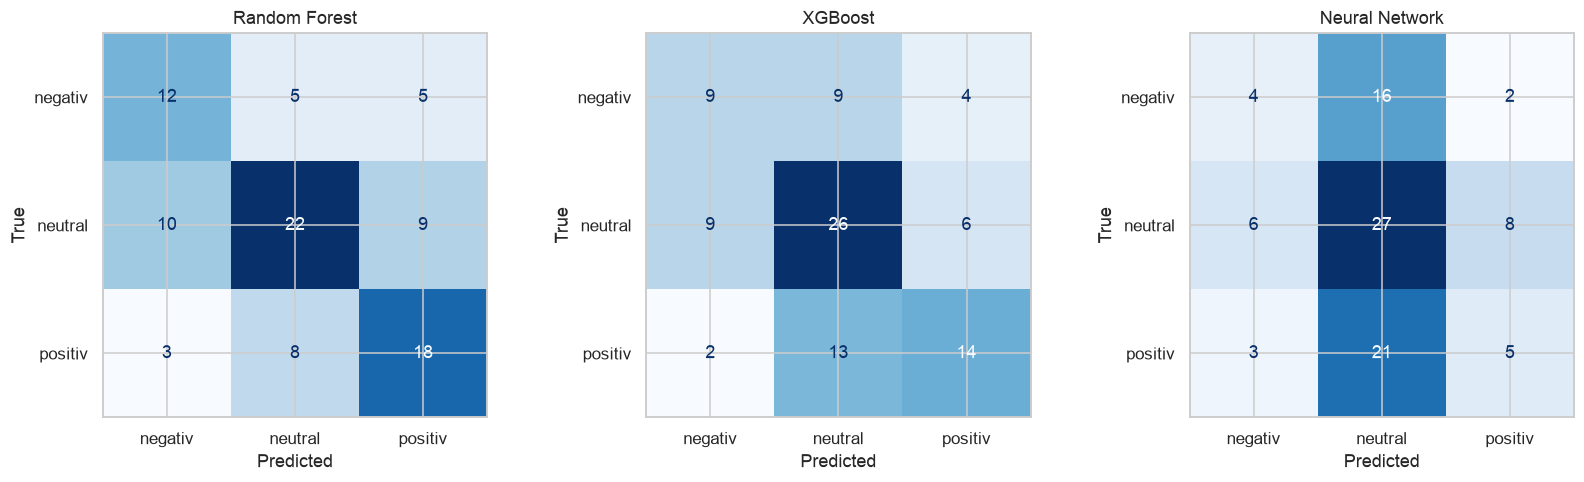

In [14]:
models_for_cm = [("Random Forest", test_preds.get("RandomForest"))]
if "XGBoost" in test_preds:
    models_for_cm.append(("XGBoost", test_preds["XGBoost"]))
models_for_cm.append(("Neural Network", test_preds.get("NeuralNet")))
models_for_cm = [(n, p) for n, p in models_for_cm if p is not None]

fig, axes = plt.subplots(1, len(models_for_cm),
                         figsize=(5 * len(models_for_cm), 4.5))
if len(models_for_cm) == 1:
    axes = [axes]
for ax, (name, y_pred) in zip(axes, models_for_cm):
    cm = confusion_matrix(y_test_enc, y_pred, labels=list(range(len(classes))))
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.show()


## 14  ROC Curves (one-vs-rest)

Because we have three classes, we draw **one-vs-rest** ROC curves: each class
against the rest, plus the macro-average AUC per model. The diagonal is chance.
A curve hugging the top-left corner indicates strong separability.


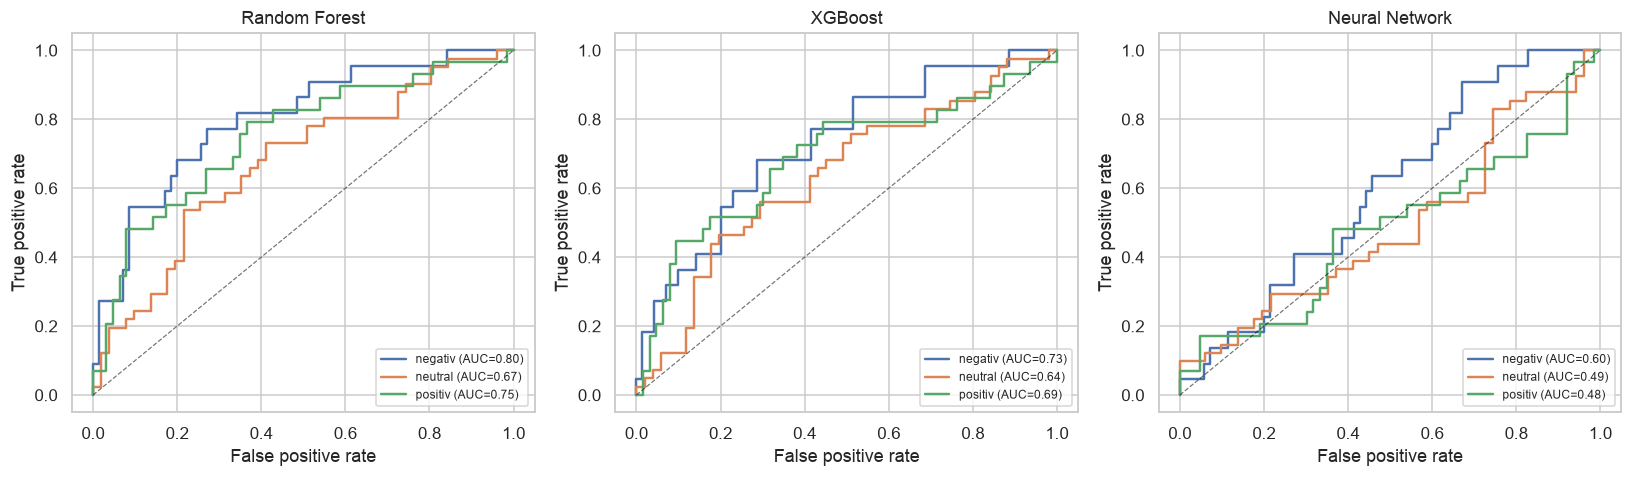

In [15]:
def plot_roc_ovr(model, X_te, y_te_enc, name, ax):
    try:
        y_proba = model.predict_proba(X_te)
    except Exception:
        ax.set_title(f"{name}: no probabilities"); return
    y_bin = label_binarize(y_te_enc, classes=list(range(len(classes))))
    for i, cls in enumerate(classes):
        if y_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        auc_i = roc_auc_score(y_bin[:, i], y_proba[:, i])
        ax.plot(fpr, tpr, lw=1.6, label=f"{cls} (AUC={auc_i:.2f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.6)
    ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
    ax.set_title(name); ax.legend(fontsize=8, loc="lower right")

panels = [("Random Forest", rf_best, S["X_test"])]
if xgb_best is not None:
    panels.append(("XGBoost", xgb_best, S["X_test"]))
panels.append(("Neural Network", mlp_best, X_test_scaled))

fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 4.5))
if len(panels) == 1: axes = [axes]
for ax, (name, model, Xte) in zip(axes, panels):
    plot_roc_ovr(model, Xte, y_test_enc, name, ax)
plt.tight_layout(); plt.show()


## 15  Feature Importance

Tree models expose impurity-based feature importances, which tell us **which
plant-signal characteristics drive the emotion prediction**. (The MLP has no
direct equivalent.) We plot the importances of the best tree model.


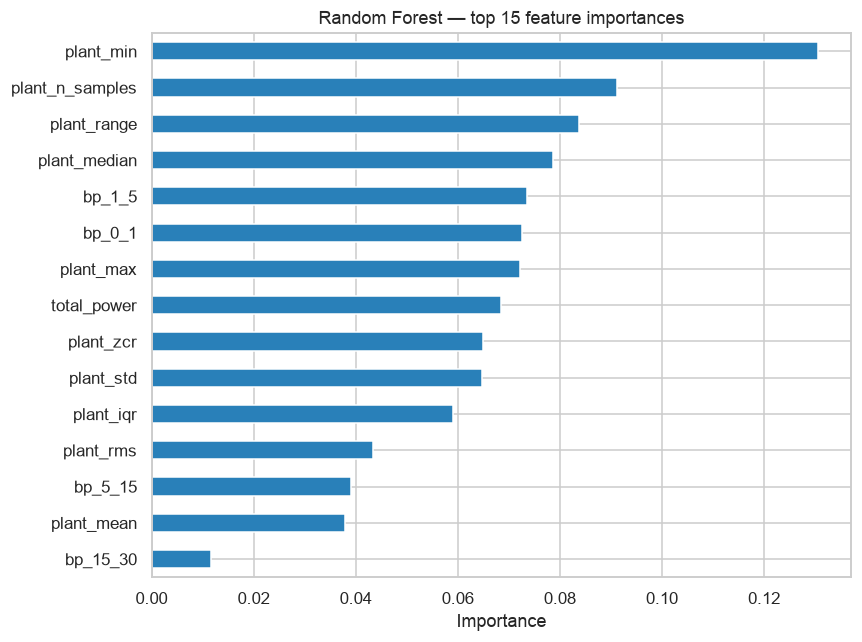

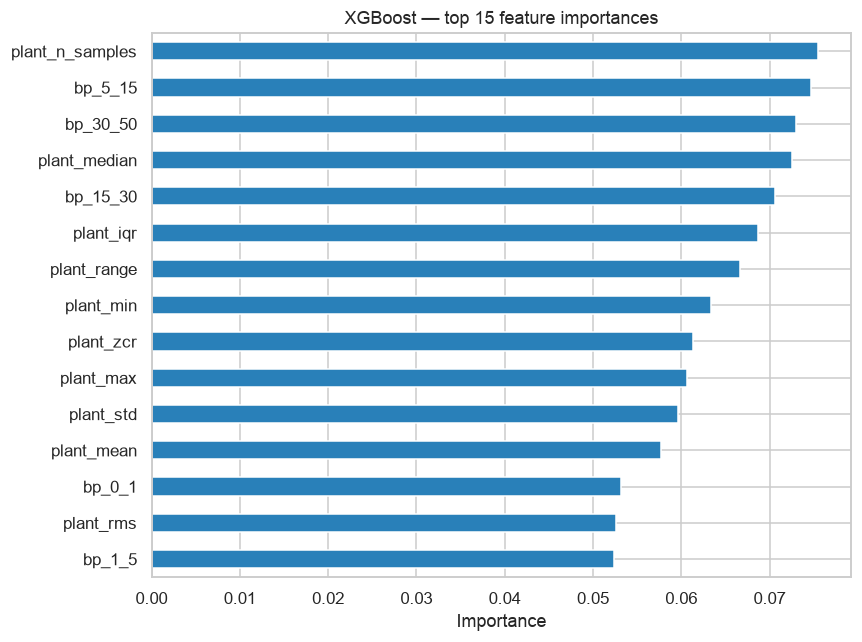

In [16]:
def plot_importance(model, feature_names, name, top_n=15):
    if not hasattr(model, "feature_importances_"):
        print(f"{name} has no feature_importances_."); return None
    imp = pd.Series(model.feature_importances_, index=feature_names)
    imp = imp.sort_values(ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(imp))))
    imp[::-1].plot.barh(ax=ax, color="#2980b9")
    ax.set_title(f"{name} — top {len(imp)} feature importances")
    ax.set_xlabel("Importance")
    plt.tight_layout(); plt.show()
    return imp

rf_imp = plot_importance(rf_best, X.columns, "Random Forest")
if xgb_best is not None:
    xgb_imp = plot_importance(xgb_best, X.columns, "XGBoost")


## 16  Final Model Comparison

We collect the test-set metrics of all three models side by side and pick the
best by **macro-F1** (the fairest single number for an imbalanced 3-class
problem).


Test-set comparison (sorted by macro-F1):

              accuracy  f1_macro  roc_auc
RandomForest     0.565     0.560    0.740
XGBoost          0.533     0.514    0.685
NeuralNet        0.391     0.323    0.524

★ Best-performing model: RandomForest


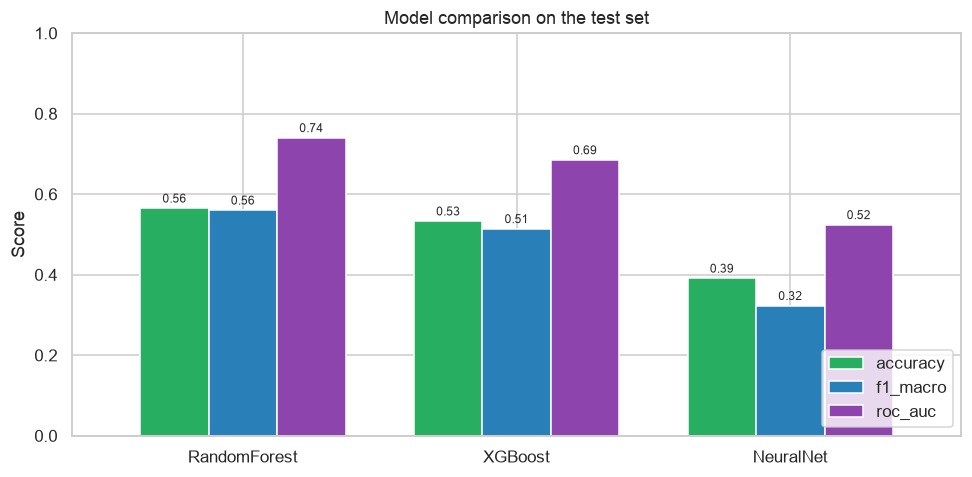

In [17]:
cmp = pd.DataFrame(test_results).T[["accuracy", "f1_macro", "roc_auc"]].round(3)
cmp = cmp.sort_values("f1_macro", ascending=False)
print("Test-set comparison (sorted by macro-F1):\n")
print(cmp.to_string())

best_overall = cmp.index[0]
print(f"\n★ Best-performing model: {best_overall}")

# Bar chart of the three metrics
ax = cmp.plot.bar(figsize=(9, 4.5), rot=0, width=0.75,
                  color=["#27ae60", "#2980b9", "#8e44ad"])
ax.set_title("Model comparison on the test set")
ax.set_ylabel("Score"); ax.set_ylim(0, 1)
ax.legend(loc="lower right")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=8, padding=2)
plt.tight_layout(); plt.show()


## 17  Discussion, Conclusions & Future Work

### Which model performed best, and why
The comparison above selects the winner by macro-F1. In small tabular problems
like this one, **gradient-boosted trees (XGBoost)** and **Random Forest**
typically outperform a neural network, because:
- tree ensembles handle modest sample sizes and mixed feature scales gracefully,
- they need little data to find threshold-style rules in the spectral band
  powers,
- a neural network usually needs more data than a pilot cohort provides and is
  more prone to over-fitting here (mitigated, not eliminated, by early stopping).

### Which features contributed most
Read this off the feature-importance plot (Section 15). We expect the
**DC-invariant** descriptors to dominate — `plant_std`, `plant_iqr`, the
spectral band powers `bp_1_5` / `bp_5_15` (the classical plant action-potential
range), and `total_power`. DC-level features (`plant_mean`, `plant_median`)
should matter *less*, since the firmware's disabled high-pass makes them drift
between sessions — a good sanity check that the model is learning signal shape,
not baseline offset.

### Honest limitations
- **Sample size.** With a pilot cohort the absolute scores carry wide
  confidence intervals; treat them as relative comparisons, not final accuracy.
- **Label provenance.** The target is an HRV-derived proxy, strongest for
  arousal, weaker for valence (see the labelling notebook's limitations).
- **Sample-rate caveat.** Spectral band edges assume the true ≈126.67 Hz rate;
  if firmware is fixed to a different rate, recompute the band powers.

### Future work
- Collect the full 10–15 participant cohort and re-run — the pipeline already
  scales without changes.
- Add engineered features straight from the raw 100 Hz `events.jsonl`
  (Hjorth parameters, spectral entropy, wavelet energy) beyond the summary
  features stored per window.
- Use **nested** cross-validation for an unbiased performance estimate once more
  data is available.
- Calibrate probabilities (Platt / isotonic) if the model's confidence is used
  downstream.

---

*End of pipeline. The consolidated dataset and both notebooks form a
reproducible path from raw multi-session recordings to a compared set of
emotion classifiers.*
